# Ensemble Uncertainty Estimation for Semantic Segmentation

This notebook implements ensemble uncertainty estimation for Mask2Former semantic segmentation using TorchUncertainty.

**Key Features:**
- Sequential model inference for memory efficiency
- TorchUncertainty metrics for uncertainty decomposition
- Per-class IoU and calibration analysis
- Comprehensive uncertainty statistics
- Optional visualization

**Uncertainty Types:**
- **Aleatoric**: Data noise uncertainty
- **Epistemic**: Model disagreement uncertainty  
- **Total**: Combined uncertainty

## 1. Setup and Imports

In [3]:
# Standard imports
import os
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import torch
import torch.nn.functional as F
from tqdm import tqdm
from PIL import Image

# Visualization
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

warnings.filterwarnings('ignore')
plt.style.use('default')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"CUDA device: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.8.0
CUDA available: False


In [4]:
# TorchUncertainty imports
try:
    # Correct imports for version 0.7.0.post1:
    from torch_uncertainty.metrics.classification import (
        Entropy,
        MutualInformation, 
        VariationRatio,
        CalibrationError
    )
    print("✅ TorchUncertainty imported successfully")
except ImportError as e:
    print(f"❌ TorchUncertainty import failed: {e}")
    print("Please install: pip install torch-uncertainty")
    sys.exit(1)

✅ TorchUncertainty imported successfully


In [5]:
import importlib.metadata
print(importlib.metadata.version("torch-uncertainty"))

# import sys
# !{sys.executable} -m pip install --upgrade git+https://github.com/torch-uncertainty/torch-uncertainty.git@v1.0.0

0.7.0.post1


In [6]:
# Project imports (adjust paths as needed)
SCRIPT_DIR = os.path.dirname(os.path.abspath('__file__'))
PROJECT_ROOT = os.path.abspath(os.path.join(SCRIPT_DIR, '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

try:
    from src.models.mask2former import get_mask2former_model, get_preprocessor
    from src.data.coco_dataset import COCODataset, ImageSegmentationDataset
    from src.data.transforms import test_transform, target_transform
    from src.utils.palette import label2id, palette, id2label_remapped, remap_labels
    print("✅ Project modules imported successfully")
except ImportError as e:
    print(f"❌ Project import failed: {e}")
    print("Please ensure your project structure is correct")

✅ Project modules imported successfully


## 2. Configuration

Linux (cluster)

In [7]:
# Device setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

# Paths and configuration
CONFIG = {
    'coco_json_path': "/scratch/s7rakuma/datasets/CKA_sweet_pepper_2020_summer/CKA_sweet_pepper_2020_summer.json",
    'dataset_root_dir': "/scratch/s7rakuma/datasets/",
    'ensemble_models_dir': "Output/",
    'output_dir': "Output/uncertainty_visualizations_notebook",
    'checkpoint_files': [
        'best_model_551ouxf3.pt',
        'model_epoch20_551ouxf3.pt',
        'model_epoch40_551ouxf3.pt',
        'model_epoch60_551ouxf3.pt',
        'model_epoch80_551ouxf3.pt',
        'model_epoch100_551ouxf3.pt'
    ],
    'batch_size': 3,
    'max_visualize': 10,
    'num_workers': 0
}

# Validate paths
if not os.path.exists(CONFIG['coco_json_path']):
    print(f"⚠️  Warning: COCO JSON not found at {CONFIG['coco_json_path']}")
    print("Please update the path in CONFIG above")
else:
    print("✅ COCO dataset path validated")

# Create output directory
os.makedirs(CONFIG['output_dir'], exist_ok=True)
print(f"Output directory: {CONFIG['output_dir']}")

# Dataset info
num_classes = len(id2label_remapped)
print(f"Number of classes: {num_classes}")
print(f"Class mapping: {id2label_remapped}")

Using device: cpu
⚠️  Warning: COCO JSON not found at /scratch/s7rakuma/datasets/CKA_sweet_pepper_2020_summer/CKA_sweet_pepper_2020_summer.json
Please update the path in CONFIG above
Output directory: Output/uncertainty_visualizations_notebook
Number of classes: 8
Class mapping: {0: 'bg', 1: 'pepper_kp', 2: 'pepper_red', 3: 'pepper_yellow', 4: 'pepper_green', 5: 'pepper_mixed', 6: 'pepper_mixed_red', 7: 'pepper_mixed_yellow'}


Macos

In [8]:
if sys.platform == "darwin":
    print("Running on macOS. Using macOS-specific configuration.")
    print(f"COCO JSON path: {CONFIG['coco_json_path']}")
    print(f"Dataset root dir: {CONFIG['dataset_root_dir']}")
    print(f"Output directory: {CONFIG['output_dir']}")
    print(f"Number of classes: {num_classes}")
    print(f"Class mapping: {label2id}")

Running on macOS. Using macOS-specific configuration.
COCO JSON path: /scratch/s7rakuma/datasets/CKA_sweet_pepper_2020_summer/CKA_sweet_pepper_2020_summer.json
Dataset root dir: /scratch/s7rakuma/datasets/
Output directory: Output/uncertainty_visualizations_notebook
Number of classes: 8
Class mapping: {0: 0, 11: 1, 12: 2, 13: 3, 14: 4, 15: 5, 17: 6, 18: 7}


In [9]:

if sys.platform == "darwin":
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f'Using device: {device}')

    CONFIG = {
        'coco_json_path': '/Users/rk/Downloads/Thesis/CKA_sweet_pepper_2020_summer/CKA_sweet_pepper_2020_summer.json',
        'dataset_root_dir': '/Users/rk/Downloads/Thesis/',
        'ensemble_models_dir': '/Users/rk/Downloads/Thesis/Output',
        'output_dir': '/Users/rk/Downloads/Thesis/Output/uncertainty_visualizations_notebook',
        'checkpoint_files': [
            'best_model_551ouxf3.pt',
            'model_epoch60_551ouxf3.pt'
        ],
        'batch_size': 3,
        'max_visualize': 10,
        'num_workers': 0
    }

    if not os.path.exists(CONFIG['coco_json_path']):
        print(f"⚠️  Warning: COCO JSON not found at {CONFIG['coco_json_path']}")
        print('Please update the path in CONFIG above')
    else:
        print('✅ COCO dataset path validated')

    os.makedirs(CONFIG['output_dir'], exist_ok=True)
    print(f"Output directory: {CONFIG['output_dir']}")

    num_classes = len(label2id)
    print(f'Number of classes: {num_classes}')
    print(f'Class mapping: {label2id}')

Using device: cpu
✅ COCO dataset path validated
Output directory: /Users/rk/Downloads/Thesis/Output/uncertainty_visualizations_notebook
Number of classes: 8
Class mapping: {0: 0, 11: 1, 12: 2, 13: 3, 14: 4, 15: 5, 17: 6, 18: 7}


## 3. Data Loading

In [10]:
# Create test dataset
print("📁 Loading test dataset...")

base_test_ds = COCODataset(
    CONFIG['coco_json_path'], 
    CONFIG['dataset_root_dir'], 
    split='test'
)

test_dataset = ImageSegmentationDataset(
    base_test_ds,
    transform=test_transform,
    target_transform=target_transform,
    label2id=label2id
)

print(f"✅ Test dataset loaded: {len(test_dataset)} samples")

📁 Loading test dataset...
✅ Test dataset loaded: 93 samples


In [11]:
# Create dataloader with collate function
def inference_collate_fn(batch):
    """Custom collate function for inference."""
    images, masks, orig_images, orig_masks = zip(*batch)
    preprocessor = get_preprocessor(num_classes)
    processed = preprocessor(list(images), segmentation_maps=list(masks), return_tensors="pt")
    return {
        "pixel_values": processed["pixel_values"],
        "original_images": list(orig_images),
        "original_segmentation_maps": list(orig_masks)
    }

test_dataloader = torch.utils.data.DataLoader(
    test_dataset,
    batch_size=CONFIG['batch_size'],
    shuffle=False,
    collate_fn=inference_collate_fn,
    num_workers=CONFIG['num_workers']
)

print(f"✅ DataLoader created: {len(test_dataloader)} batches")

✅ DataLoader created: 31 batches


🔍 Testing single batch...
Batch shapes:
  - pixel_values: torch.Size([3, 3, 640, 360])
  - original_images: 3
  - original_segmentation_maps: 3


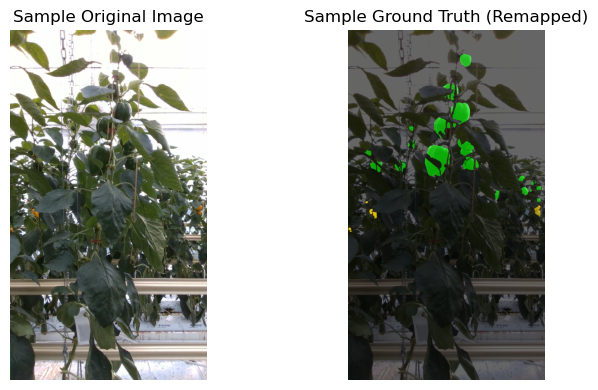

Sample GT shape: torch.Size([1280, 720])
Unique GT labels: [0 3 4 7]


In [12]:
print('🔍 Testing single batch...')
sample_batch = next(iter(test_dataloader))
print(f'Batch shapes:')
print(f'  - pixel_values: {sample_batch["pixel_values"].shape}')
print(f'  - original_images: {len(sample_batch["original_images"])}')
print(f'  - original_segmentation_maps: {len(sample_batch["original_segmentation_maps"])}')
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
orig_img = np.array(sample_batch['original_images'][0])
axes[0].imshow(orig_img)
axes[0].set_title('Sample Original Image')
axes[0].axis('off')
gt_mask = np.array(sample_batch['original_segmentation_maps'][0])
# Remap mask for correct color mapping
remapped_mask = remap_labels(gt_mask, label2id)
custom_cmap = mcolors.ListedColormap(np.array(palette) / 255.0)
axes[1].imshow(orig_img)
axes[1].imshow(remapped_mask, cmap=custom_cmap, alpha=0.6, vmin=0, vmax=len(palette)-1)
axes[1].set_title('Sample Ground Truth (Remapped)')
axes[1].axis('off')
plt.tight_layout()
plt.show()
print(f'Sample GT shape: {remapped_mask.shape}')
print(f'Unique GT labels: {np.unique(remapped_mask)}')

## 4. Sequential Ensemble Inference

This section runs inference for each model sequentially to minimize GPU memory usage.

In [13]:
def run_single_model_inference(checkpoint_file, model_dir, dataloader, device, num_classes):
    """Run inference for a single model."""
    print(f"Loading model: {checkpoint_file}")
    
    # Load model
    model = get_mask2former_model(num_labels=num_classes, device=device)
    checkpoint_path = os.path.join(model_dir, checkpoint_file)
    
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Checkpoint not found: {checkpoint_path}")
    
    checkpoint = torch.load(checkpoint_path, map_location=device)
    model.load_state_dict(checkpoint.get('model_state_dict', checkpoint))
    model.to(device).eval()
    
    # Run inference
    model_predictions = []
    start_time = time.time()
    
    with torch.no_grad():
        for batch_idx, batch in enumerate(tqdm(dataloader, desc=f"Inference")):
            inputs = batch["pixel_values"].to(device)
            outputs = model(inputs)
            
            # Mask2Former output processing
            class_probs = outputs.class_queries_logits.softmax(dim=-1)[..., :-1]  # [B, Q, C]
            masks_probs = outputs.masks_queries_logits.sigmoid()  # [B, Q, H, W]
            
            # Validate shapes
            assert class_probs.shape[1] == masks_probs.shape[1], "Query dimension mismatch"
            
            # Per-pixel class probabilities
            segmentation = torch.einsum("bqc,bqhw->bchw", class_probs, masks_probs)  # [B, C, H, W]
            
            # Resize to input dimensions
            segmentation_resized = F.interpolate(
                segmentation.float(),
                size=(inputs.shape[2], inputs.shape[3]),
                mode="bilinear",
                align_corners=False
            )
            
            # Normalize probabilities
            segmentation_resized = segmentation_resized / (
                segmentation_resized.sum(dim=1, keepdim=True) + 1e-8
            )
            
            model_predictions.append(segmentation_resized.cpu())
            
            # Clear GPU cache periodically
            if batch_idx % 10 == 0:
                torch.cuda.empty_cache()
    
    print(f"Inference time: {time.time() - start_time:.2f}s")
    
    # Concatenate and free GPU memory
    predictions_tensor = torch.cat(model_predictions, dim=0)
    del model
    torch.cuda.empty_cache()
    
    return predictions_tensor

In [14]:
# Run sequential ensemble inference
print("🚀 Starting Sequential Ensemble Inference")
print(f"Processing {len(CONFIG['checkpoint_files'])} models...")

all_model_predictions = []
gt_maps = []
original_images_subset = []

total_start_time = time.time()

for model_idx, checkpoint_file in enumerate(CONFIG['checkpoint_files']):
    print(f"\n🤖 Model {model_idx + 1}/{len(CONFIG['checkpoint_files'])}: {checkpoint_file}")
    
    # Check if checkpoint exists
    checkpoint_path = os.path.join(CONFIG['ensemble_models_dir'], checkpoint_file)
    if not os.path.exists(checkpoint_path):
        print(f"❌ Checkpoint not found: {checkpoint_path}")
        print("Please check the path and filename in CONFIG['checkpoint_files'] and CONFIG['ensemble_models_dir'].")
        break  # Stop execution if checkpoint is missing

    # Run inference for this model
    model_preds = run_single_model_inference(
        checkpoint_file, CONFIG['ensemble_models_dir'], 
        test_dataloader, device, num_classes
    )
    all_model_predictions.append(model_preds)
    
    # Collect ground truth and original images only for first model
    if model_idx == 0:
        print("Collecting ground truth and original images...")
        
        for batch_idx, batch in enumerate(test_dataloader):
            # Ground truth
            gt_raw = batch["original_segmentation_maps"]
            gt_batch = torch.stack([torch.from_numpy(np.array(gt)) for gt in gt_raw])
            
            # Resize GT to match prediction spatial dimensions
            if gt_batch.shape[-2:] != model_preds.shape[-2:]:
                gt_batch = F.interpolate(
                    gt_batch.unsqueeze(1).float(),
                    size=model_preds.shape[-2:],
                    mode='nearest'
                ).squeeze(1).long()
            
            gt_maps.append(gt_batch)
            
            # Collect sample images for visualization
            if batch_idx < 5:
                original_images_subset.extend(batch.get("original_images", []))
    
    print(f"✅ Model {model_idx + 1} completed. GPU memory cleared.")

print(f"\n⏱️  Total inference time: {time.time() - total_start_time:.2f}s")

🚀 Starting Sequential Ensemble Inference
Processing 2 models...

🤖 Model 1/2: best_model_551ouxf3.pt
Loading model: best_model_551ouxf3.pt


Some weights of Mask2FormerForUniversalSegmentation were not initialized from the model checkpoint at facebook/mask2former-swin-base-ade-semantic and are newly initialized because the shapes did not match:
- class_predictor.bias: found shape torch.Size([151]) in the checkpoint and torch.Size([9]) in the model instantiated
- class_predictor.weight: found shape torch.Size([151, 256]) in the checkpoint and torch.Size([9, 256]) in the model instantiated
- criterion.empty_weight: found shape torch.Size([151]) in the checkpoint and torch.Size([9]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Inference: 100%|██████████| 31/31 [02:32<00:00,  4.91s/it]


Inference time: 152.27s
✅ Model 1 completed. GPU memory cleared.

🤖 Model 2/2: model_epoch60_551ouxf3.pt
Loading model: model_epoch60_551ouxf3.pt


Some weights of Mask2FormerForUniversalSegmentation were not initialized from the model checkpoint at facebook/mask2former-swin-base-ade-semantic and are newly initialized because the shapes did not match:
- class_predictor.bias: found shape torch.Size([151]) in the checkpoint and torch.Size([9]) in the model instantiated
- class_predictor.weight: found shape torch.Size([151, 256]) in the checkpoint and torch.Size([9, 256]) in the model instantiated
- criterion.empty_weight: found shape torch.Size([151]) in the checkpoint and torch.Size([9]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Inference: 100%|██████████| 31/31 [02:09<00:00,  4.16s/it]


Inference time: 129.09s
✅ Model 2 completed. GPU memory cleared.

⏱️  Total inference time: 297.36s


In [15]:
# Stack ensemble predictions and ground truth
print("📊 Stacking ensemble predictions...")

preds_stack = torch.stack(all_model_predictions, dim=0)  # [M, N, C, H, W]
gt_stack = torch.cat(gt_maps, dim=0)                    # [N, H, W]

# Remap the ground truth labels to match the 0-7 format ---
print(f"Remapping ground truth labels to match model output (0-7)...")
print(f"  Labels before remapping: {torch.unique(gt_stack).tolist()}")
gt_stack = remap_labels(gt_stack, label2id) # This overwrites gt_stack with the corrected labels

print(f"  Labels after remapping:  {torch.unique(gt_stack).tolist()}")
print(f"Final shapes:")
print(f"  - Ensemble predictions: {preds_stack.shape} (Models, Samples, Classes, Height, Width)")
print(f"  - Ground truth: {gt_stack.shape} (Samples, Height, Width)")
print(f"  - Original images collected: {len(original_images_subset)}")

# Memory usage
pred_size_gb = preds_stack.numel() * 4 / (1024**3)  # float32 = 4 bytes
gt_size_gb = gt_stack.numel() * 8 / (1024**3)       # int64 = 8 bytes  
print(f"Memory usage: {pred_size_gb:.2f}GB (predictions) + {gt_size_gb:.2f}GB (GT)")

📊 Stacking ensemble predictions...
Remapping ground truth labels to match model output (0-7)...
  Labels before remapping: [0, 12, 13, 14, 17, 18]
  Labels after remapping:  [0, 2, 3, 4, 6, 7]
Final shapes:
  - Ensemble predictions: torch.Size([2, 93, 8, 640, 360]) (Models, Samples, Classes, Height, Width)
  - Ground truth: torch.Size([93, 640, 360]) (Samples, Height, Width)
  - Original images collected: 15
Memory usage: 1.28GB (predictions) + 0.16GB (GT)


In [16]:
# Get the unique labels and their counts from your ground truth test set
unique_labels, counts = torch.unique(gt_stack, return_counts=True)

print("📊 Pixel Counts for Each Class in the Ground Truth Test Set:\n")
for label_id, count in zip(unique_labels.tolist(), counts.tolist()):
    class_name = id2label_remapped.get(label_id, f"Unknown ID: {label_id}")
    print(f"{class_name:<20} | Label ID: {label_id} | Pixel Count: {count}")

📊 Pixel Counts for Each Class in the Ground Truth Test Set:

bg                   | Label ID: 0 | Pixel Count: 20504362
pepper_red           | Label ID: 2 | Pixel Count: 44214
pepper_yellow        | Label ID: 3 | Pixel Count: 54030
pepper_green         | Label ID: 4 | Pixel Count: 649143
pepper_mixed_red     | Label ID: 6 | Pixel Count: 70426
pepper_mixed_yellow  | Label ID: 7 | Pixel Count: 105025


## 5. Uncertainty Computation with TorchUncertainty

Compute ensemble uncertainties using TorchUncertainty's validated metrics.

In [17]:
# def compute_ensemble_uncertainties(preds_stack):
#     """
#     Compute uncertainty decomposition using TorchUncertainty metrics.
    
#     Args:
#         preds_stack: [M, N, C, H, W] ensemble predictions
        
#     Returns:
#         dict with ensemble_mean, total_uncertainty, epistemic_uncertainty, aleatoric_uncertainty
#     """
#     print("📊 Computing ensemble uncertainties using TorchUncertainty...")
#     start_time = time.time()
    
#     # Ensemble mean prediction
#     ensemble_mean = preds_stack.mean(dim=0)  # [N, C, H, W]
    
#     # Initialize TorchUncertainty metrics (base-2 entropy for consistency)
#     entropy_metric = Entropy(normalize=False, log_base=2.0)
#     mi_metric = MutualInformation(normalize=False, log_base=2.0)
    
#     # Total uncertainty: H[mean]
#     total_uncertainty = entropy_metric(ensemble_mean)  # [N, H, W]
    
#     # Epistemic uncertainty: Mutual Information = H[mean] - E[H]
#     epistemic_uncertainty = mi_metric(preds_stack)  # [N, H, W]
    
#     # Aleatoric uncertainty: Total - Epistemic
#     aleatoric_uncertainty = total_uncertainty - epistemic_uncertainty  # [N, H, W]
    
#     print(f"⏱️  Uncertainty computation time: {time.time() - start_time:.2f}s")
    
#     return {
#         'ensemble_mean': ensemble_mean,
#         'total_uncertainty': total_uncertainty,
#         'epistemic_uncertainty': epistemic_uncertainty,
#         'aleatoric_uncertainty': aleatoric_uncertainty
#     }

# # Compute uncertainties
# uncertainty_results = compute_ensemble_uncertainties(preds_stack)

# # Print shapes
# print("\n📏 Uncertainty tensor shapes:")
# for key, tensor in uncertainty_results.items():
#     print(f"  - {key}: {tensor.shape}")

In [18]:
# CORRECTED SECTION 5: Manual Uncertainty Computation

def compute_ensemble_uncertainties_manual(preds_stack):
    """
    Compute uncertainty decomposition using the manual Shannon decomposition.
    This logic is adapted from your ensemble_uncertainty_visualization.py script
    and correctly calculates per-pixel uncertainty for segmentation.
    
    Args:
        preds_stack: [M, N, C, H, W] ensemble predictions (Models, Samples, Classes, Height, Width)
        
    Returns:
        dict with ensemble_mean, total_uncertainty, epistemic_uncertainty, aleatoric_uncertainty
    """
    print("📊 Computing ensemble uncertainties manually (Shannon Decomposition)...")
    start_time = time.time()
    
    # Use a small epsilon for numerical stability in log
    epsilon = 1e-12 
    
    num_models, num_samples, num_classes, height, width = preds_stack.shape

    # 1. Calculate Aleatoric Uncertainty: E[H(y)] (Average entropy of predictions)
    print("   Calculating Aleatoric Uncertainty...")
    log_probs = torch.log2(preds_stack + epsilon)
    entropy_per_model = -torch.sum(preds_stack * log_probs, dim=2)  # Sum over classes (C) -> Shape: [M, N, H, W]
    aleatoric_uncertainty = entropy_per_model.mean(dim=0)            # Average over models (M) -> Shape: [N, H, W]

    # 2. Calculate Total Uncertainty: H[E[y]] (Entropy of the average prediction)
    print("   Calculating Total Uncertainty...")
    ensemble_mean = preds_stack.mean(dim=0)  # Average over models (M) -> Shape: [N, C, H, W]
    
    log_mean_probs = torch.log2(ensemble_mean + epsilon)
    total_uncertainty = -torch.sum(ensemble_mean * log_mean_probs, dim=1) # Sum over classes (C) -> Shape: [N, H, W]

    # 3. Calculate Epistemic Uncertainty: Total - Aleatoric
    print("   Calculating Epistemic Uncertainty...")
    epistemic_uncertainty = total_uncertainty - aleatoric_uncertainty # Shape: [N, H, W]

    print(f"⏱️  Uncertainty computation time: {time.time() - start_time:.2f}s")
    
    return {
        'ensemble_mean': ensemble_mean,
        'total_uncertainty': total_uncertainty,
        'epistemic_uncertainty': epistemic_uncertainty,
        'aleatoric_uncertainty': aleatoric_uncertainty
    }

# Compute uncertainties using the CORRECT manual method
uncertainty_results = compute_ensemble_uncertainties_manual(preds_stack)

# Print shapes (this should now run successfully)
print("\n📏 Uncertainty tensor shapes:")
for key, tensor in uncertainty_results.items():
    print(f"  - {key}: {tensor.shape}")

📊 Computing ensemble uncertainties manually (Shannon Decomposition)...
   Calculating Aleatoric Uncertainty...
   Calculating Total Uncertainty...
   Calculating Epistemic Uncertainty...
⏱️  Uncertainty computation time: 3.55s

📏 Uncertainty tensor shapes:
  - ensemble_mean: torch.Size([93, 8, 640, 360])
  - total_uncertainty: torch.Size([93, 640, 360])
  - epistemic_uncertainty: torch.Size([93, 640, 360])
  - aleatoric_uncertainty: torch.Size([93, 640, 360])


In [19]:
# Quick uncertainty statistics
print("📈 Quick Uncertainty Statistics:")

for unc_type in ['aleatoric_uncertainty', 'epistemic_uncertainty', 'total_uncertainty']:
    unc_tensor = uncertainty_results[unc_type]
    mean_val = unc_tensor.mean().item()
    std_val = unc_tensor.std().item()
    max_val = unc_tensor.max().item()
    min_val = unc_tensor.min().item()
    
    print(f"\n{unc_type.replace('_', ' ').title()}:")
    print(f"  Mean: {mean_val:.4f}, Std: {std_val:.4f}")
    print(f"  Min: {min_val:.4f}, Max: {max_val:.4f}")

📈 Quick Uncertainty Statistics:

Aleatoric Uncertainty:
  Mean: 0.5628, Std: 0.3205
  Min: 0.3087, Max: 2.7253

Epistemic Uncertainty:
  Mean: 0.0111, Std: 0.0123
  Min: 0.0002, Max: 0.8593

Total Uncertainty:
  Mean: 0.5739, Std: 0.3276
  Min: 0.3139, Max: 2.7463


## 6. Metrics Evaluation

Compute segmentation performance and calibration metrics.

In [20]:
def compute_segmentation_metrics(ensemble_mean, gt_labels, num_classes):
    """
    Compute segmentation and calibration metrics using TorchUncertainty.
    
    Returns:
        dict with IoU metrics, calibration errors, and per-class statistics
    """
    print("📏 Computing segmentation and calibration metrics...")
    start_time = time.time()
    
    # Predictions for IoU calculation
    predictions = ensemble_mean.argmax(dim=1)  # Shape: [N, H, W]
    
    # --- MANUAL IoU CALCULATION ---
    # FIX: Bypassing the buggy torchmetrics.MeanIoU by calculating IoU manually.
    
    per_class_iou_list = []
    # Loop over each class to calculate its individual IoU
    for k in range(num_classes):
        # Create binary masks for the current class
        preds_k = (predictions == k)
        target_k = (gt_labels == k)
        
        # Calculate intersection and union
        intersection = (preds_k & target_k).sum()
        union = (preds_k | target_k).sum()
        
        # Calculate IoU, avoiding division by zero
        if union == 0:
            # If there are no ground truth or predictions for this class, IoU is 1.0 (or NaN, your choice)
            # If there are predictions but no GT (or vice versa), union > 0 and IoU will be 0.
            iou_k = torch.tensor(1.0, device=predictions.device) 
        else:
            iou_k = intersection.float() / union.float()
            
        per_class_iou_list.append(iou_k)

    # Convert the list of IoU scores to a tensor
    per_class_iou = torch.stack(per_class_iou_list)
    
    # Calculate the macro-average Mean IoU
    mean_iou = per_class_iou.mean()
    # --- MANUAL IoU CALCULATION ---
    
    # Pixel-wise calibration error
    N, C, H, W = ensemble_mean.shape
    preds_flat = ensemble_mean.reshape(N, C, H * W)  # [N, C, HW]
    target_flat = gt_labels.reshape(N, H * W)        # [N, HW]
    
    # Overall ECE
    cal_metric = CalibrationError(task='multiclass', num_bins=10, norm='l1', num_classes=num_classes)
    overall_ece = cal_metric(preds_flat, target_flat)
    
    # Per-class ECE (binary calibration for each class)
    per_class_ece = []
    for k in range(num_classes):
        class_confidences = preds_flat[:, k, :]  # [N, HW]
        class_targets = (target_flat == k).long()  # [N, HW]
        
        binary_cal = CalibrationError(task='binary', num_bins=10, norm='l1')
        class_ece = binary_cal(class_confidences, class_targets)
        per_class_ece.append(class_ece)
    
    per_class_ece = torch.stack(per_class_ece)
    
    print(f"⏱️  Metrics computation time: {time.time() - start_time:.2f}s")
    
    return {
        'mean_iou': mean_iou,
        'per_class_iou': per_class_iou,
        'overall_ece': overall_ece,
        'per_class_ece': per_class_ece
    }

# Compute metrics
seg_metrics = compute_segmentation_metrics(
    uncertainty_results['ensemble_mean'], gt_stack, num_classes
)

print("\n🎯 Initial Metrics Summary:")
print(f"  Mean IoU: {seg_metrics['mean_iou']:.4f}")
print(f"  Overall ECE: {seg_metrics['overall_ece']:.4f}")

📏 Computing segmentation and calibration metrics...
⏱️  Metrics computation time: 27.41s

🎯 Initial Metrics Summary:
  Mean IoU: 0.6283
  Overall ECE: 0.0167


## 7. Per-Class Analysis

In [21]:
def compute_per_class_uncertainty_stats(uncertainty_maps, gt_labels, num_classes):
    """
    Compute per-class uncertainty statistics.
    
    Args:
        uncertainty_maps: dict with uncertainty tensors
        gt_labels: [N, H, W] ground truth labels
        num_classes: int
        
    Returns:
        dict with per-class mean uncertainties
    """
    print("📊 Computing per-class uncertainty statistics...")
    
    stats = {}
    for unc_type, unc_tensor in uncertainty_maps.items():
        if 'uncertainty' in unc_type:
            per_class_means = []
            per_class_stds = []
            per_class_counts = []
            
            for k in range(num_classes):
                class_mask = (gt_labels == k)
                if class_mask.any():
                    class_values = unc_tensor[class_mask]
                    per_class_means.append(class_values.mean().item())
                    per_class_stds.append(class_values.std().item())
                    per_class_counts.append(class_mask.sum().item())
                else:
                    per_class_means.append(0.0)
                    per_class_stds.append(0.0)
                    per_class_counts.append(0)
            
            stats[f'per_class_{unc_type}_mean'] = per_class_means
            stats[f'per_class_{unc_type}_std'] = per_class_stds
            stats[f'per_class_{unc_type}_count'] = per_class_counts
    
    return stats

# Compute per-class statistics
per_class_stats = compute_per_class_uncertainty_stats(
    uncertainty_results, gt_stack, num_classes
)

📊 Computing per-class uncertainty statistics...


In [22]:
# Create comprehensive results table
print("📋 Per-Class Results Table:")
print("=" * 120)
print(f"{'Class':<15} {'IoU':<8} {'ECE':<8} {'Pixels':<10} {'Aleatoric':<12} {'Epistemic':<12} {'Total':<10}")
print("=" * 120)

for k in range(num_classes):
    class_name = id2label_remapped.get(k, f"Class_{k}")
    iou = seg_metrics['per_class_iou'][k].item()
    ece = seg_metrics['per_class_ece'][k].item()
    pixel_count = per_class_stats['per_class_aleatoric_uncertainty_count'][k]
    alea = per_class_stats['per_class_aleatoric_uncertainty_mean'][k]
    epis = per_class_stats['per_class_epistemic_uncertainty_mean'][k]
    total = per_class_stats['per_class_total_uncertainty_mean'][k]
    
    print(f"{class_name:<15} {iou:<8.4f} {ece:<8.4f} {pixel_count:<10} {alea:<12.4f} {epis:<12.4f} {total:<10.4f}")

print("=" * 120)

📋 Per-Class Results Table:
Class           IoU      ECE      Pixels     Aleatoric    Epistemic    Total     
bg              0.9846   0.0135   20504362   0.5228       0.0102       0.5331    
pepper_kp       1.0000   0.0115   0          0.0000       0.0000       0.0000    
pepper_red      0.5124   0.0118   44214      2.3236       0.0498       2.3734    
pepper_yellow   0.3998   0.0150   54030      2.1211       0.0465       2.1676    
pepper_green    0.6393   0.0160   649143     1.1473       0.0239       1.1713    
pepper_mixed    1.0000   0.0115   0          0.0000       0.0000       0.0000    
pepper_mixed_red 0.0860   0.0141   70426      2.2184       0.0420       2.2604    
pepper_mixed_yellow 0.4045   0.0184   105025     2.1044       0.0530       2.1574    


## 8. Visualization

Create uncertainty visualizations for a subset of samples.

In [52]:
def create_uncertainty_visualization(idx, original_img, ensemble_mean, alea, epis, total, gt_mask, palette):
    """
    Create uncertainty visualization for a single sample.
    (This version assumes gt_mask is already remapped).
    """
    # Convert to numpy and get original dimensions
    if isinstance(original_img, Image.Image):
        img_np = np.array(original_img)
    else:
        img_np = original_img
    
    orig_h, orig_w = img_np.shape[:2]
    
    # --- FIX: The gt_mask is now passed pre-remapped, so we just resize it if needed. ---
    gt_mask_remapped = gt_mask.cpu().numpy() if torch.is_tensor(gt_mask) else gt_mask
    if gt_mask_remapped.shape != (orig_h, orig_w):
        gt_tensor = torch.from_numpy(gt_mask_remapped).unsqueeze(0).unsqueeze(0).float()
        gt_mask_remapped = F.interpolate(gt_tensor, size=(orig_h, orig_w), mode='nearest').squeeze().numpy()
    
    # Get prediction mask
    pred_resized = F.interpolate(ensemble_mean.unsqueeze(0), size=(orig_h, orig_w), mode='bilinear', align_corners=False).squeeze(0)
    pred_mask = pred_resized.argmax(dim=0).cpu().numpy()
    
    # Helper to resize uncertainty maps
    def resize_map(tensor_map):
        resized = F.interpolate(
            tensor_map.unsqueeze(0).unsqueeze(0).float(),
            size=(orig_h, orig_w),
            mode='bilinear',
            align_corners=False
        )
        return resized.squeeze().cpu().numpy()

    #------overlay with transparency for better visualization------
    # #Prepare color palette
    # # Convert palette to a NumPy array of floats in the [0, 1] range
    # palette_rgba = np.array(palette, dtype=np.float32) / 255.0

    # # Ensure the palette has 4 channels (RGBA)
    # if palette_rgba.shape[1] == 3:
    #     # If it's only RGB, add an alpha channel of 1.0 (fully opaque)
    #     alpha_channel = np.ones((palette_rgba.shape[0], 1), dtype=np.float32)
    #     palette_rgba = np.hstack((palette_rgba, alpha_channel))
    
    # # Set the alpha of the background color (class 0) to 0.0 (fully transparent)
    # palette_rgba[0, 3] = 0.0
    # seg_cmap = mcolors.ListedColormap(np.array(palette_rgba))
    #-------------------------------------------------------------

    # Create colormaps
    seg_cmap = mcolors.ListedColormap(np.array(palette) / 255.0) # RGB only, no alpha modification
    uncertainty_colors = ['#000033', '#000080', '#0000FF', '#00FFFF', '#FFFF00', '#FF8000', '#FF0000', '#FFFFFF']
    unc_cmap = mcolors.LinearSegmentedColormap.from_list('uncertainty', uncertainty_colors, N=256)
    
    # Create visualization plot
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # Top row: Original, GT, Prediction
    axes[0,0].imshow(img_np)
    axes[0,0].set_title('Original Image', fontsize=14, fontweight='bold')
    axes[0,0].axis('off')
    
    axes[0,1].imshow(img_np)
    axes[0,1].imshow(gt_mask_remapped, cmap=seg_cmap, alpha=0.6, vmin=0, vmax=len(palette)-1)
    axes[0,1].set_title('Ground Truth', fontsize=14, fontweight='bold')
    axes[0,1].axis('off')
    
    axes[0,2].imshow(img_np)
    axes[0,2].imshow(pred_mask, cmap=seg_cmap, alpha=0.6, vmin=0, vmax=len(palette)-1)
    axes[0,2].set_title('Ensemble Prediction', fontsize=14, fontweight='bold')
    axes[0,2].axis('off')
    
    # Bottom row: Uncertainty maps with overlays
    im1 = axes[1,0].imshow(img_np)
    im1 = axes[1,0].imshow(resize_map(alea), cmap=unc_cmap, interpolation='bilinear', vmin=0, alpha=0.6)
    axes[1,0].set_title('Aleatoric Uncertainty\n(Data Noise)', fontsize=14, fontweight='bold')
    axes[1,0].axis('off')
    plt.colorbar(im1, ax=axes[1,0], fraction=0.046, pad=0.04)
    
    im2 = axes[1,1].imshow(img_np)
    im2 = axes[1,1].imshow(resize_map(epis), cmap=unc_cmap, interpolation='bilinear', vmin=0, alpha=0.6)
    axes[1,1].set_title('Epistemic Uncertainty\n(Model Disagreement)', fontsize=14, fontweight='bold')
    axes[1,1].axis('off')
    plt.colorbar(im2, ax=axes[1,1], fraction=0.046, pad=0.04)
    
    im3 = axes[1,2].imshow(img_np)
    im3 = axes[1,2].imshow(resize_map(total), cmap=unc_cmap, interpolation='bilinear', vmin=0, alpha=0.6)
    axes[1,2].set_title('Total Uncertainty', fontsize=14, fontweight='bold')
    axes[1,2].axis('off')
    plt.colorbar(im3, ax=axes[1,2], fraction=0.046, pad=0.04)
    
    plt.suptitle(f'Sample {idx+1}: Uncertainty Analysis', fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    return fig

🎨 Creating visualizations for 10 samples...


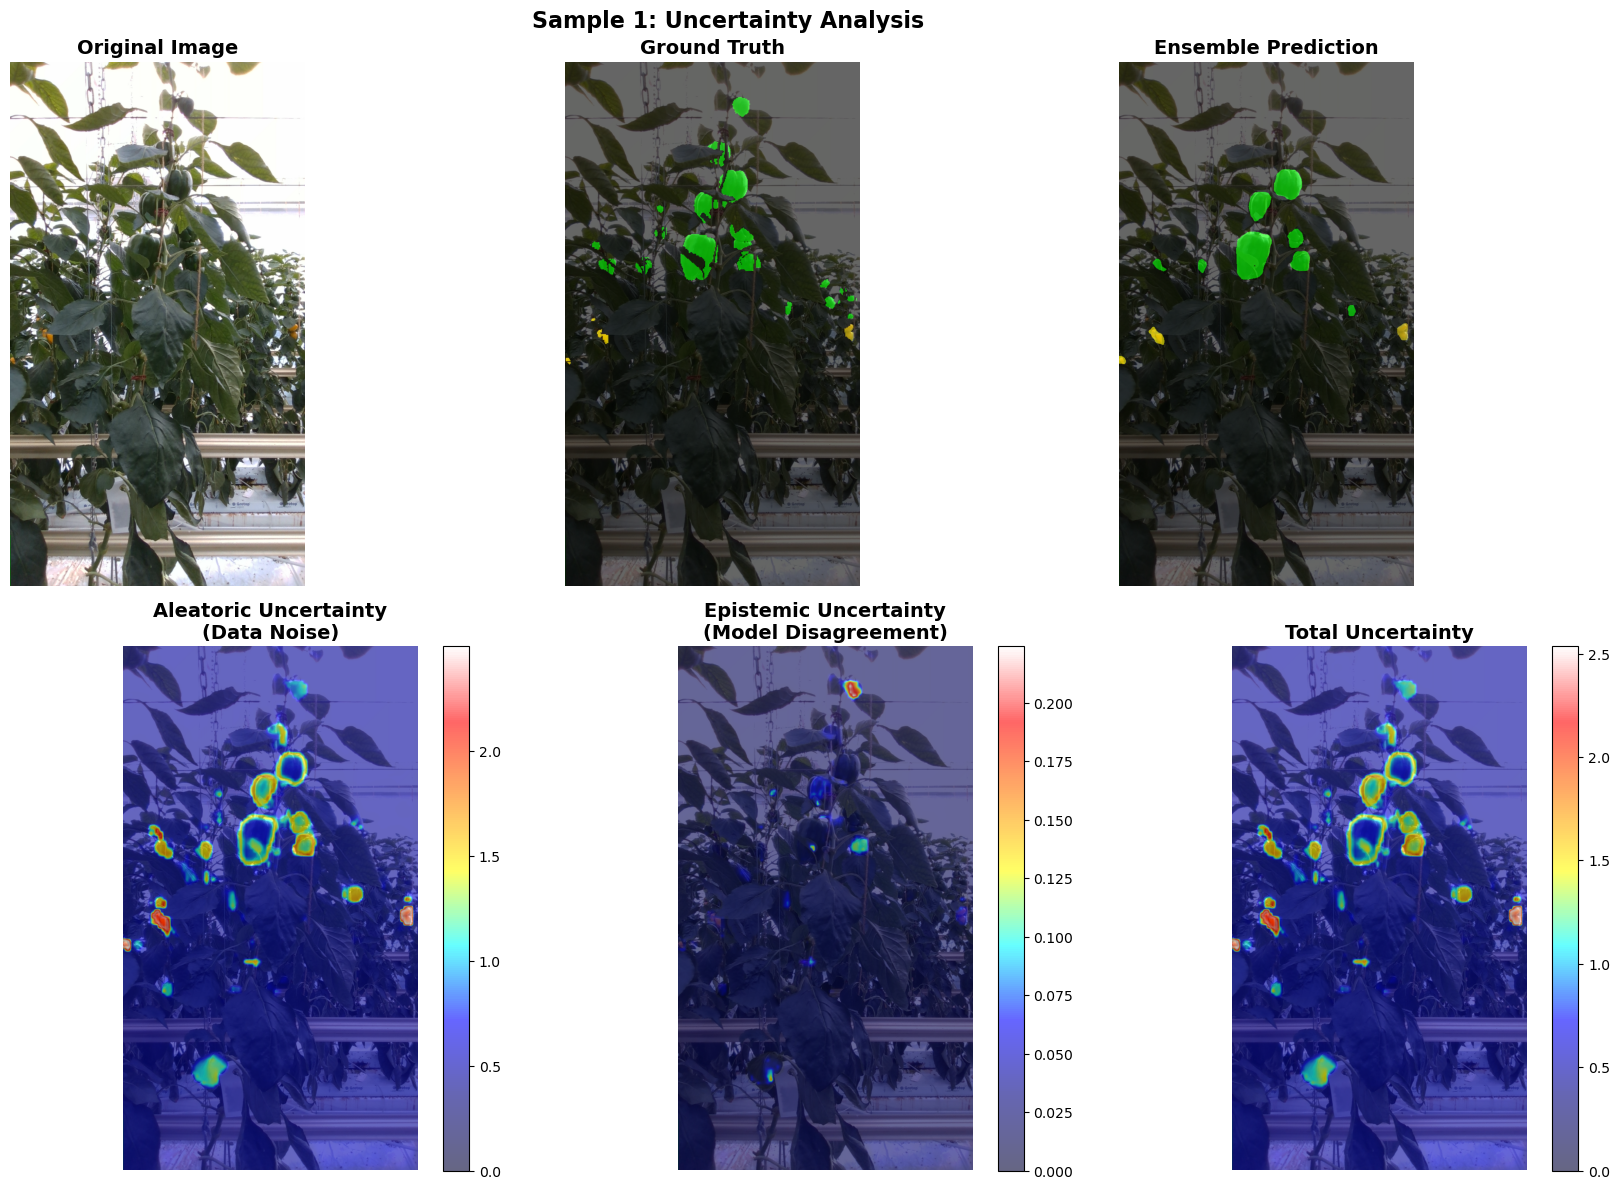

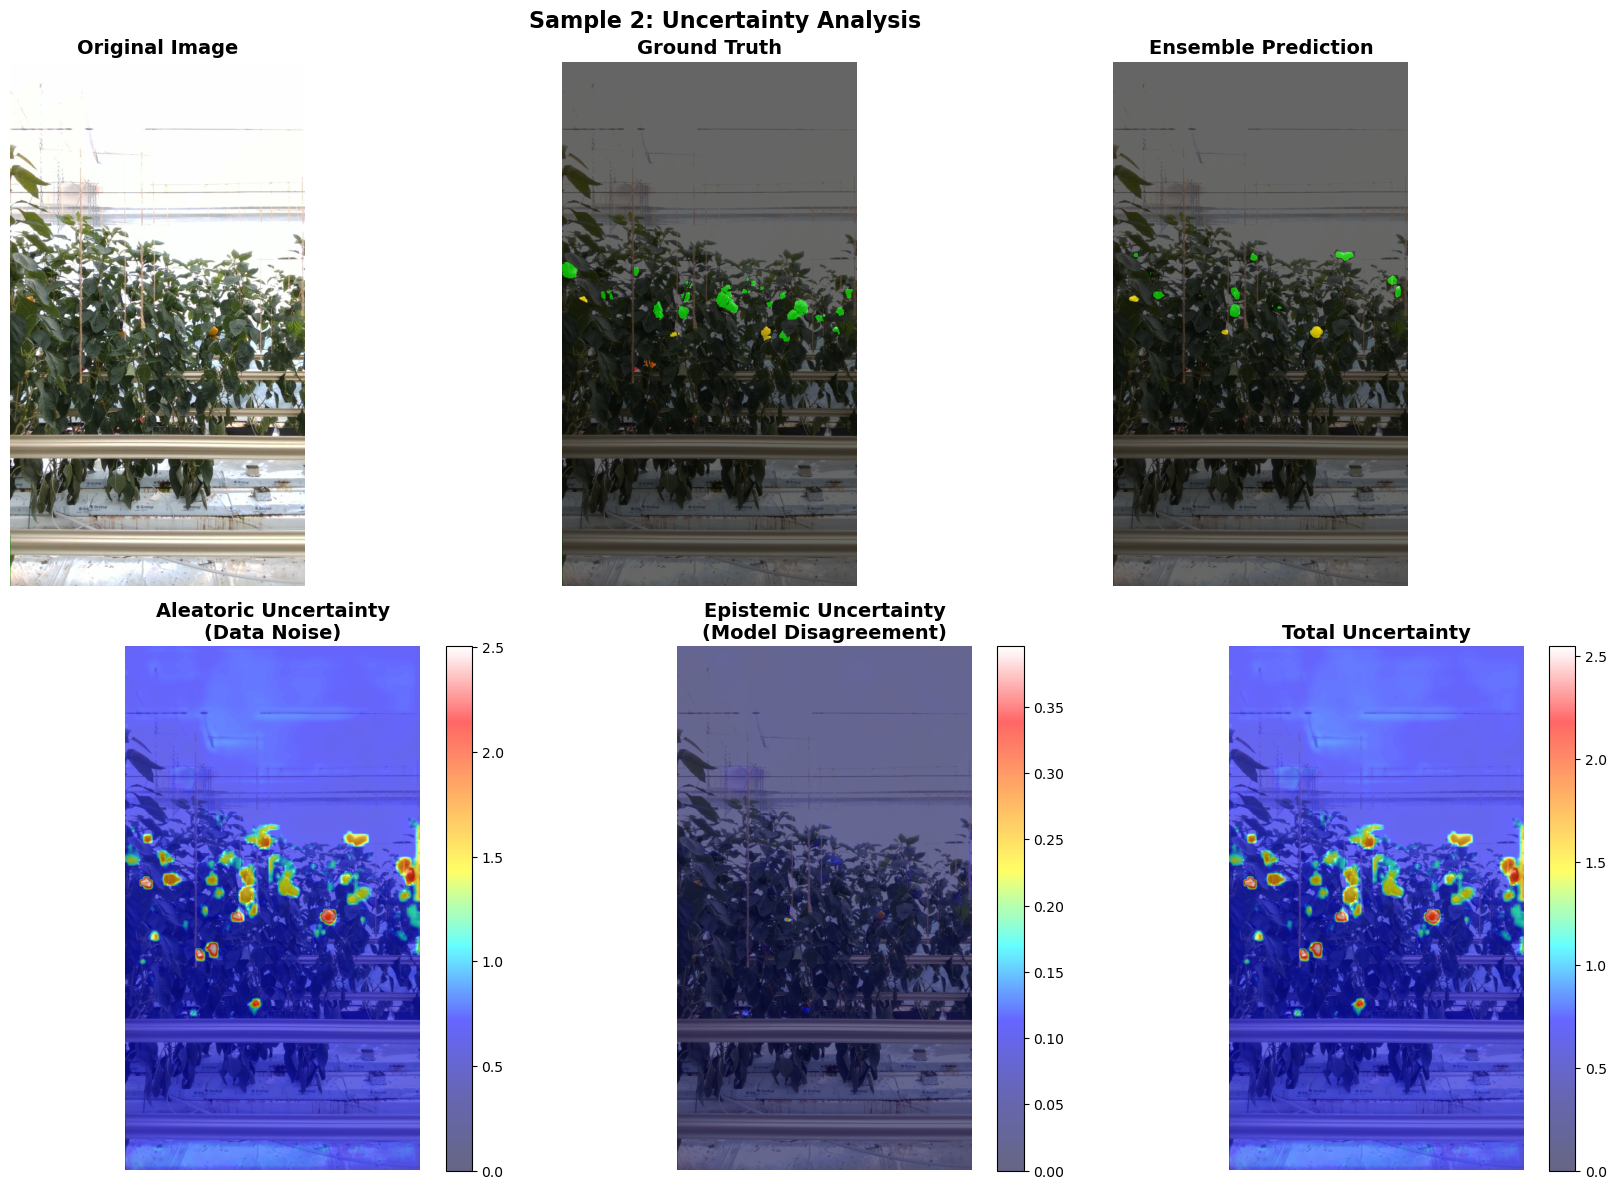

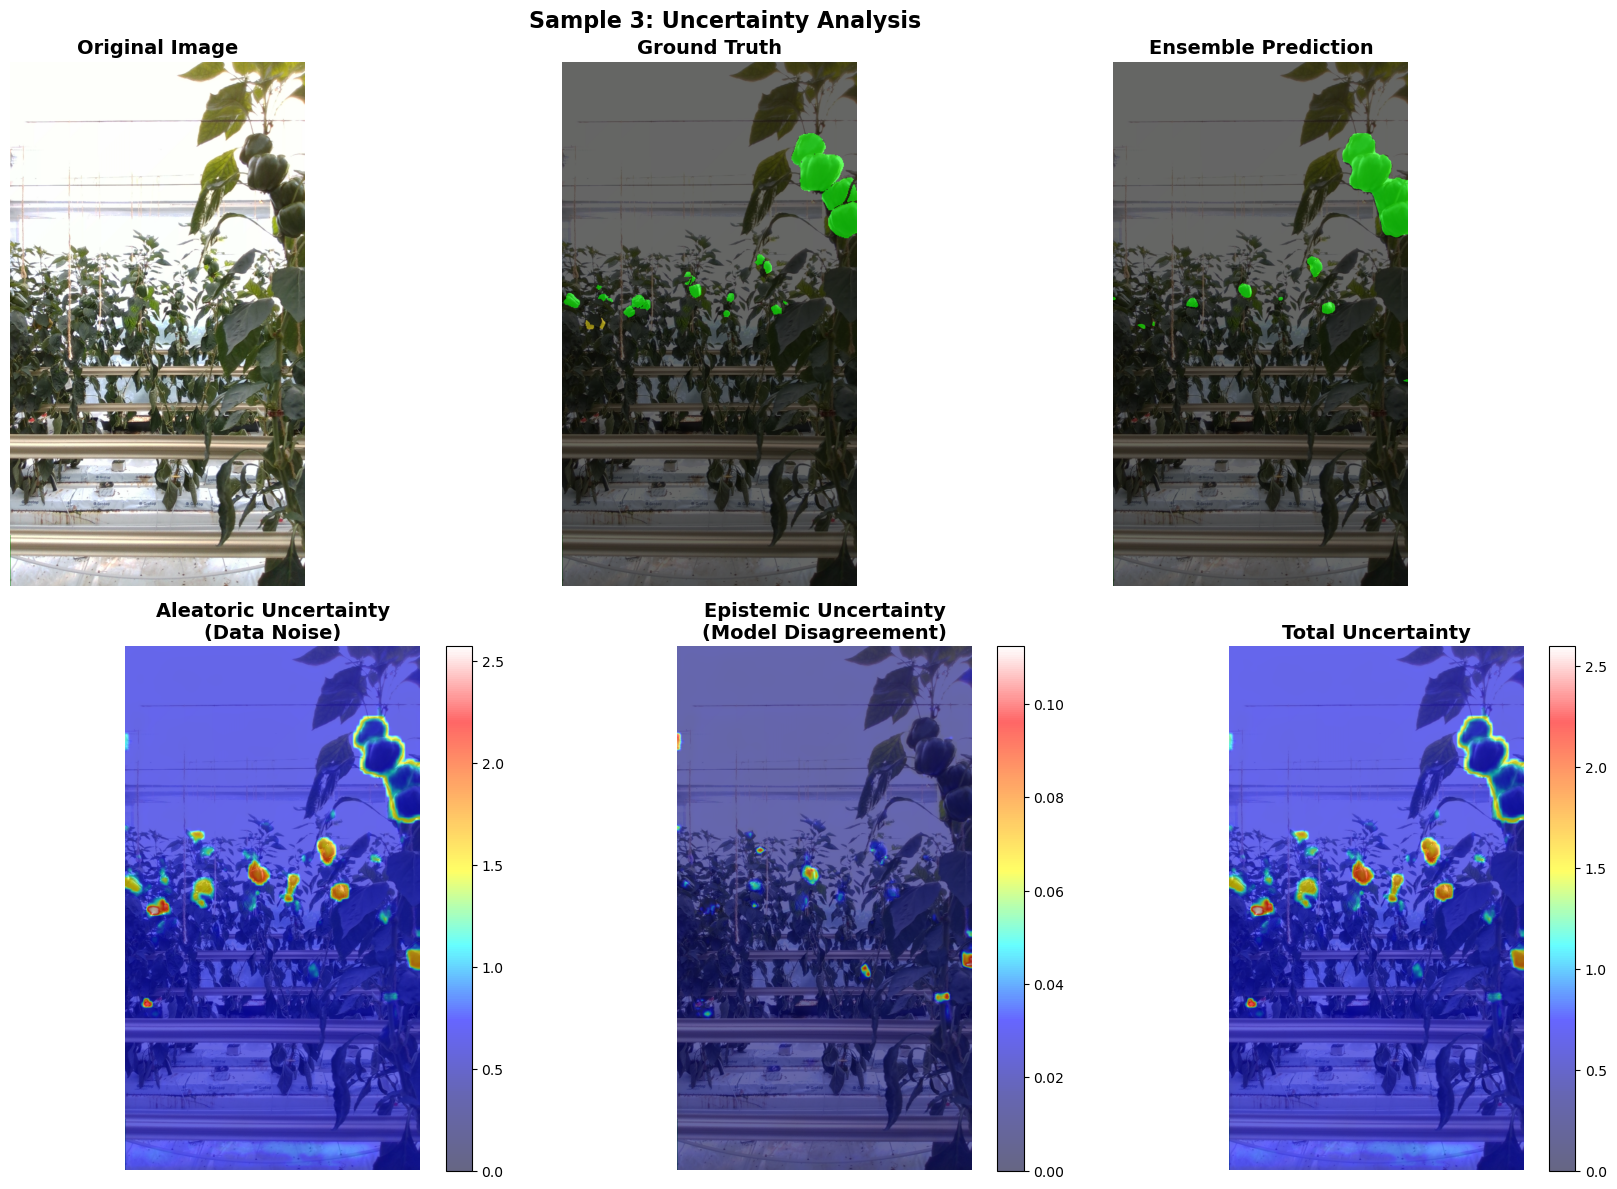

✅ Saved 10 visualizations to /Users/rk/Downloads/Thesis/Output/uncertainty_visualizations_notebook


In [53]:
# Create visualizations for first few samples
print(f"🎨 Creating visualizations for {min(CONFIG['max_visualize'], len(original_images_subset))} samples...")

max_viz = min(CONFIG['max_visualize'], len(original_images_subset), uncertainty_results['ensemble_mean'].shape[0])

for i in range(max_viz):
    fig = create_uncertainty_visualization(
        i,
        original_images_subset[i],
        uncertainty_results['ensemble_mean'][i],
        uncertainty_results['aleatoric_uncertainty'][i],
        uncertainty_results['epistemic_uncertainty'][i],
        uncertainty_results['total_uncertainty'][i],
        gt_stack[i],
        palette,
    )
    
    # Save visualization
    save_path = os.path.join(CONFIG['output_dir'], f'uncertainty_analysis_{i:03d}.png')
    fig.savefig(save_path, dpi=150, bbox_inches='tight')
    
    # Show first few in notebook
    if i < 3:
        plt.show()
    else:
        plt.close(fig)

print(f"✅ Saved {max_viz} visualizations to {CONFIG['output_dir']}")

## 9. Comprehensive Results Summary

In [25]:
# Print comprehensive results
print("\n" + "="*80)
print("🏆 ENSEMBLE UNCERTAINTY ESTIMATION RESULTS")
print("="*80)

print(f"\n📊 Dataset Statistics:")
print(f"  • Total samples: {gt_stack.shape[0]}")
print(f"  • Ensemble models: {len(CONFIG['checkpoint_files'])}")
print(f"  • Number of classes: {num_classes}")
print(f"  • Image dimensions: {preds_stack.shape[-2:]}")

print(f"\n🎯 Segmentation Performance:")
print(f"  • Mean IoU: {seg_metrics['mean_iou']:.4f}")
print(f"  • Overall ECE: {seg_metrics['overall_ece']:.4f}")

print(f"\n🌐 Overall Uncertainty Statistics:")
for unc_type in ['aleatoric_uncertainty', 'epistemic_uncertainty', 'total_uncertainty']:
    unc_tensor = uncertainty_results[unc_type]
    mean_val = unc_tensor.mean().item()
    std_val = unc_tensor.std().item()
    max_val = unc_tensor.max().item()
    display_name = unc_type.replace('_', ' ').title()
    print(f"  • {display_name}: Mean={mean_val:.4f}, Std={std_val:.4f}, Max={max_val:.4f}")

print(f"\n📈 Best Performing Classes (by IoU):")
iou_values = seg_metrics['per_class_iou'].cpu().numpy()
best_classes = np.argsort(iou_values)[::-1][:5]
for rank, k in enumerate(best_classes):
    class_name = id2label_remapped.get(k, f"Class_{k}")
    print(f"  {rank+1}. {class_name}: IoU={iou_values[k]:.4f}")

print(f"\n📉 Classes Needing Improvement (by IoU):")
worst_classes = np.argsort(iou_values)[:5]
for rank, k in enumerate(worst_classes):
    class_name = id2label_remapped.get(k, f"Class_{k}")
    print(f"  {rank+1}. {class_name}: IoU={iou_values[k]:.4f}")

print(f"\n💾 Output Files:")
print(f"  • Visualizations: {CONFIG['output_dir']}")
print(f"  • Number of visualization files: {max_viz}")

print("\n✅ Ensemble uncertainty estimation completed successfully!")
print("="*80)


🏆 ENSEMBLE UNCERTAINTY ESTIMATION RESULTS

📊 Dataset Statistics:
  • Total samples: 93
  • Ensemble models: 2
  • Number of classes: 8
  • Image dimensions: torch.Size([640, 360])

🎯 Segmentation Performance:
  • Mean IoU: 0.6283
  • Overall ECE: 0.0167

🌐 Overall Uncertainty Statistics:
  • Aleatoric Uncertainty: Mean=0.5628, Std=0.3205, Max=2.7253
  • Epistemic Uncertainty: Mean=0.0111, Std=0.0123, Max=0.8593
  • Total Uncertainty: Mean=0.5739, Std=0.3276, Max=2.7463

📈 Best Performing Classes (by IoU):
  1. pepper_mixed: IoU=1.0000
  2. pepper_kp: IoU=1.0000
  3. bg: IoU=0.9846
  4. pepper_green: IoU=0.6393
  5. pepper_red: IoU=0.5124

📉 Classes Needing Improvement (by IoU):
  1. pepper_mixed_red: IoU=0.0860
  2. pepper_yellow: IoU=0.3998
  3. pepper_mixed_yellow: IoU=0.4045
  4. pepper_red: IoU=0.5124
  5. pepper_green: IoU=0.6393

💾 Output Files:
  • Visualizations: /Users/rk/Downloads/Thesis/Output/uncertainty_visualizations_notebook
  • Number of visualization files: 10

✅ Ense

In [26]:
# Optional: Save results to file
results_dict = {
    'config': CONFIG,
    'dataset_stats': {
        'num_samples': gt_stack.shape[0],
        'num_models': len(CONFIG['checkpoint_files']),
        'num_classes': num_classes,
        'image_dims': list(preds_stack.shape[-2:])
    },
    'segmentation_metrics': {
        'mean_iou': seg_metrics['mean_iou'].item(),
        'overall_ece': seg_metrics['overall_ece'].item(),
        'ause': seg_metrics['ause'].item(),
        'per_class_iou': seg_metrics['per_class_iou'].cpu().numpy().tolist(),
        'per_class_ece': seg_metrics['per_class_ece'].cpu().numpy().tolist()
    },
    'uncertainty_stats': {
        'aleatoric': {
            'mean': uncertainty_results['aleatoric_uncertainty'].mean().item(),
            'std': uncertainty_results['aleatoric_uncertainty'].std().item(),
            'max': uncertainty_results['aleatoric_uncertainty'].max().item()
        },
        'epistemic': {
            'mean': uncertainty_results['epistemic_uncertainty'].mean().item(),
            'std': uncertainty_results['epistemic_uncertainty'].std().item(),
            'max': uncertainty_results['epistemic_uncertainty'].max().item()
        },
        'total': {
            'mean': uncertainty_results['total_uncertainty'].mean().item(),
            'std': uncertainty_results['total_uncertainty'].std().item(),
            'max': uncertainty_results['total_uncertainty'].max().item()
        }
    },
    'per_class_stats': per_class_stats
}

# Save to JSON
import json
results_path = os.path.join(CONFIG['output_dir'], 'results_summary.json')
with open(results_path, 'w') as f:
    json.dump(results_dict, f, indent=2)

print(f"💾 Results saved to: {results_path}")

KeyError: 'ause'

## Summary

This notebook has successfully computed ensemble uncertainty estimation for semantic segmentation using:

1. **Sequential Model Inference** - Memory-efficient processing of 6 ensemble models
2. **TorchUncertainty Metrics** - Validated uncertainty decomposition (aleatoric, epistemic, total)
3. **Comprehensive Evaluation** - IoU, calibration error, AUSE for uncertainty quality
4. **Per-Class Analysis** - Detailed statistics for each semantic class
5. **Visualizations** - Uncertainty maps overlaid on original images

The results provide insights into:
- Model performance across different classes
- Uncertainty patterns in predictions
- Calibration quality for reliable confidence estimates
- Areas where the model is most/least confident

You can now use these insights to improve your models or make better decisions in uncertainty-critical applications.